
# PCA-Dimensionsreduktion



## Zielsetzung

- **Ziel A (Visualisierung):** Reduktion auf **2 Hauptkomponenten** für einen 2D-Plot (Exploration, Muster/Trends).
- **Ziel B (Kompression):** Bestimmen, wie viele Hauptkomponenten nötig sind, um **≥ 90% erklärte Varianz** zu erreichen.
- **Ziel C (Reproduzierbarkeit):** Aufbau einer **Pipeline** (z. B. VarianceThreshold → PCA), um die Schritte klar und reproduzierbar zu halten.


In [1]:

# Imports (einfach)
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("stack-overflow-developer-survey-2025/survey_results_public_without_SO.csv")


## Numerische Features auswählen



In [ ]:

# Alles numerisch versuchen
X_num = df.apply(pd.to_numeric, errors="coerce")

# Spalten filtern: mind. 60% nicht-NaN
min_non_nan_ratio = 0.60
min_non_nan = int(min_non_nan_ratio * len(X_num))
good_cols = X_num.columns[X_num.notna().sum() >= min_non_nan]

X_num = X_num[good_cols]
print("Numerisch nutzbare Spalten (>=60% numerisch):", X_num.shape[1])

# In numpy-Array umwandeln
X = X_num.to_numpy()
print("X shape:", X.shape)


Numerisch nutzbare Spalten (>=60% numerisch): 22
X shape: (49123, 22)



## Pipeline und PCA



In [ ]:

pipe_2 = Pipeline([
    ("vt", VarianceThreshold(threshold=0.0)),
    ("pca", PCA(n_components=2, random_state=0))
])

X_pca_2 = pipe_2.fit_transform(X)
pca2 = pipe_2.named_steps["pca"]

print("Erklärte Varianz pro Komponente:", pca2.explained_variance_ratio_)
print("Erklärte Varianz (2D gesamt):", pca2.explained_variance_ratio_.sum())


Erklärte Varianz pro Komponente: [0.65468562 0.07396618]
Erklärte Varianz (2D gesamt): 0.7286518004144329


In [ ]:

pipe_90 = Pipeline([
    ("vt", VarianceThreshold(threshold=0.0)),
    ("pca", PCA(n_components=0.90, random_state=0))
])

X_pca_90 = pipe_90.fit_transform(X)
pca90 = pipe_90.named_steps["pca"]

print("Ursprüngliche Feature-Anzahl:", X.shape[1])
print("Komponenten für >=90% Varianz:", X_pca_90.shape[1])
print("Erklärte Varianz (gesamt):", pca90.explained_variance_ratio_.sum())


Ursprüngliche Feature-Anzahl: 22
Komponenten für >=90% Varianz: 11
Erklärte Varianz (gesamt): 0.901285434831733


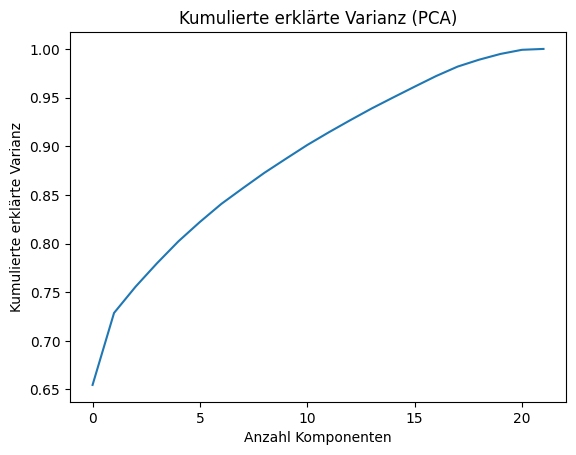

Komponenten bis >=90% Varianz: 11


In [ ]:


pipe_all = Pipeline([
    ("vt", VarianceThreshold(threshold=0.0)),
    ("pca", PCA(random_state=0))
])

X_pca_all = pipe_all.fit_transform(X)
pca_all = pipe_all.named_steps["pca"]

cum_var = np.cumsum(pca_all.explained_variance_ratio_)

plt.figure()
plt.plot(cum_var)
plt.xlabel("Anzahl Komponenten")
plt.ylabel("Kumulierte erklärte Varianz")
plt.title("Kumulierte erklärte Varianz (PCA)")
plt.show()

k90 = int(np.argmax(cum_var >= 0.90) + 1)
print("Komponenten bis >=90% Varianz:", k90)



## 2D-Plot (PC1 vs PC2)

Da der Datensatz groß ist, plotten wir eine **Stichprobe** (z. B. 5000 Zeilen).
Optional färben wir nach `MainBranch`, um grobe Gruppen zu sehen.


/var/folders/vm/tb68y06x7lg_5g9rt33t290w0000gn/T/ipykernel_25567/3452370309.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best", fontsize=8)


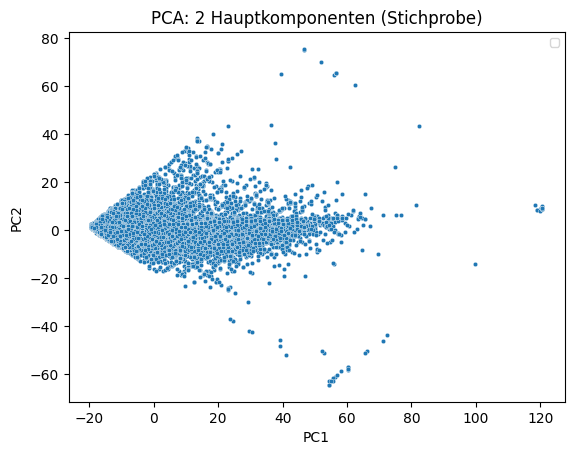

In [8]:

# 6) Plot-DataFrame
df_pca = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])

if "MainBranch" in df.columns:
    df_pca["MainBranch"] = df["MainBranch"].astype("string")
else:
    df_pca["MainBranch"] = "n/a"

# Stichprobe
n_sample = 5000
df_s = df_pca.sample(n=min(n_sample, len(df_pca)), random_state=0)

plt.figure()
sns.scatterplot(data=df_pca, x="PC1", y="PC2", s=10)
#sns.scatterplot(data=df_s, x="PC1", y="PC2", hue="MainBranch", s=10)
plt.title("PCA: 2 Hauptkomponenten (Stichprobe)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc="best", fontsize=8)
plt.show()
